
# 7.8: Parallelism: Using the MPI backend

This example demonstrates how to use the MPI backend for simulating dipoles using `hnn_core`.

`hnn_core` can take advantage of MPI libraries such as [OpenMPI](https://www.open-mpi.org/) to run a **single** simulation using **multiple** CPU processors. MPI lets you divide parts of your simulated network across CPUs while allowing the CPUs to "talk" to each other, and can therefore enable *significant* speed-up of individual simulations.

Note that to use MPI parallelism, you need either the `conda` install **or** the `pip` `MPI Installation` dependencies described [in our Installation Guide here](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html).

Note that MPI parallelism is distinct from `hnn_core`'s use of [Joblib parallelism, which can be found here](https://jonescompneurolab.github.io/textbook/content/08_using_hnn_api/parallelism_joblib.html).

Authors:

- Mainak Jas ( mjas@mgh.harvard.edu )
- Blake Caldwell ( blake_caldwell@brown.edu )
- Austin Soplata ( austin_soplata@brown.edu )

## 1. Import MPI dependencies

**Please note that in order to run this tutorial you MUST have installed HNN-Core with MPI support, which requires multiple steps. Normally, this is optional for general HNN-Core use, but it is required for this tutorial. In the next cell, we will check to make sure MPI support is installed, and if it is not, then please follow the directions provided.**

In [1]:
try:
    import mpi4py  # noqa: F401
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "MPI parallelism for HNN-Core has not been installed correctly. "
        "Please follow the directions for installing MPI support at \n" \
        "\n" \
        " https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html \n" \
        "\n" \
        "The easiest way to install HNN-Core with MPI support is to use the `conda Package Installation` method described in the link above."
    ) from None


After following the above instructions, we should be able to import `MPIBackend` with full parallelism support.

In [2]:
from hnn_core import MPIBackend

--No graphics will be displayed.


## 2. Import other dependencies

Let us import what else we need from `hnn_core` and `matplotlib`:

In [3]:
import matplotlib.pyplot as plt

from hnn_core import simulate_dipole, neymotin_2020_model
from hnn_core.viz import plot_dipole

## 3. Setup our network

Following our [Alpha example](https://jonescompneurolab.github.io/textbook/content/06_alpha_beta/api.html), we will create our network and add a ~10 Hz "bursty" drive:

In [4]:
net = neymotin_2020_model()

weights_ampa = {'L2_pyramidal': 5.4e-5, 'L5_pyramidal': 5.4e-5}
net.add_bursty_drive(
    'bursty', tstart=50., burst_rate=10, burst_std=20., numspikes=2,
    spike_isi=10, n_drive_cells=10, location='distal',
    weights_ampa=weights_ampa, event_seed=278)

## 4. Simulate using `MPIBackend`

Finally, we will simulate using the
[`MPIBackend` class](https://jonescompneurolab.github.io/hnn-core/stable/generated/hnn_core.parallel_backends.MPIBackend.html#hnn_core.parallel_backends.MPIBackend). This will start the simulation across the number of processors (cores) specified by `n_procs` using MPI.

In [5]:
with MPIBackend(n_procs=4, mpi_cmd='mpiexec'):
    dpls = simulate_dipole(net, tstop=210., n_trials=1)

MPI will run 1 trial(s) sequentially by distributing network neurons over 4 processes.
numprocs=4
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 

## 5. Visualize our output

Having used `MPIBackend`, our simulation should have run considerably faster than it would using only a single core, approximately 4 times faster!

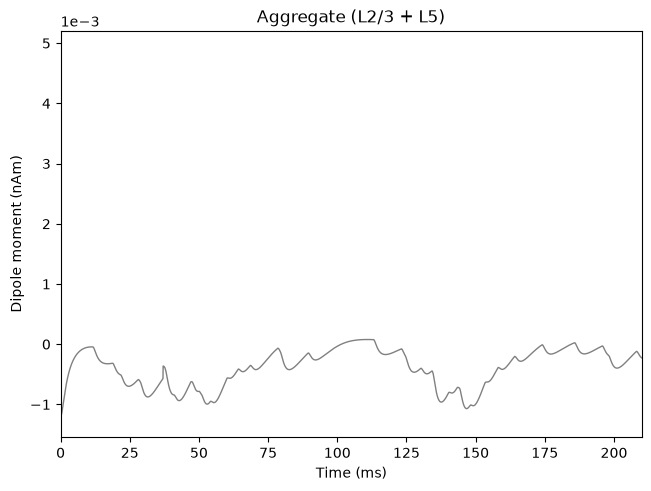

In [6]:
plot_dipole(dpls, show=False)
plt.show()